In [34]:
!pip install praat-parselmouth



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import librosa
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
song_paths = {
    "Kanye West": "./song1/kanye.mp3",
    "Cardi B": "./song2/wap.mp3",
    "Elton John": "./song3/islandgirl.mp3",
    "Tom Macdonald": "./song4/whiteboy.mp3"
}
max_duration = 360  # Compare first 3 minutes
songs = {}

for name, path in song_paths.items():
    y, sr = librosa.load(path, duration=max_duration, mono=True)
    songs[name] = {"y": y, "sr": sr}

In [7]:
song_sections = {
    "Kanye West": [
        (0, 50, "Verse 1"),
        (51, 76, "Chorus"),
        (77, 90, "Verse 2"),
        (91, 161, "Chorus")
    ],
    "Cardi B": [
        (0, 14, "Intro"),
        (15, 28, "Chorus"),
        (29, 56, "Verse 1"),
        (57, 71, "Verse 2"),
        (72, 85, "Chorus"),
        (86, 115, "Verse 3"),
        (116, 137, "Verse 4"),
        (138, 165, "Chorus"),
        (166, 187, "Outro"),
    ],
    "Elton John": [
        (0, 33, "Verse 1"),
        (34, 69, "Chorus"),
        (70, 102, "Verse 2"),
        (103, 222, "Chorus"),
    ],
    "Tom Macdonald": [
        (0, 50, "Verse 1"),
        (51, 72, "Chorus"),
        (73, 107, "Verse 2"),
        (108, 129, "Chorus"),
        (130, 176, "Verse 3"),
        (177, 220, "Verse 4"),
        (221, 231, "Bridge"),
        (232, 271, "Chorus")
        
    ]
}

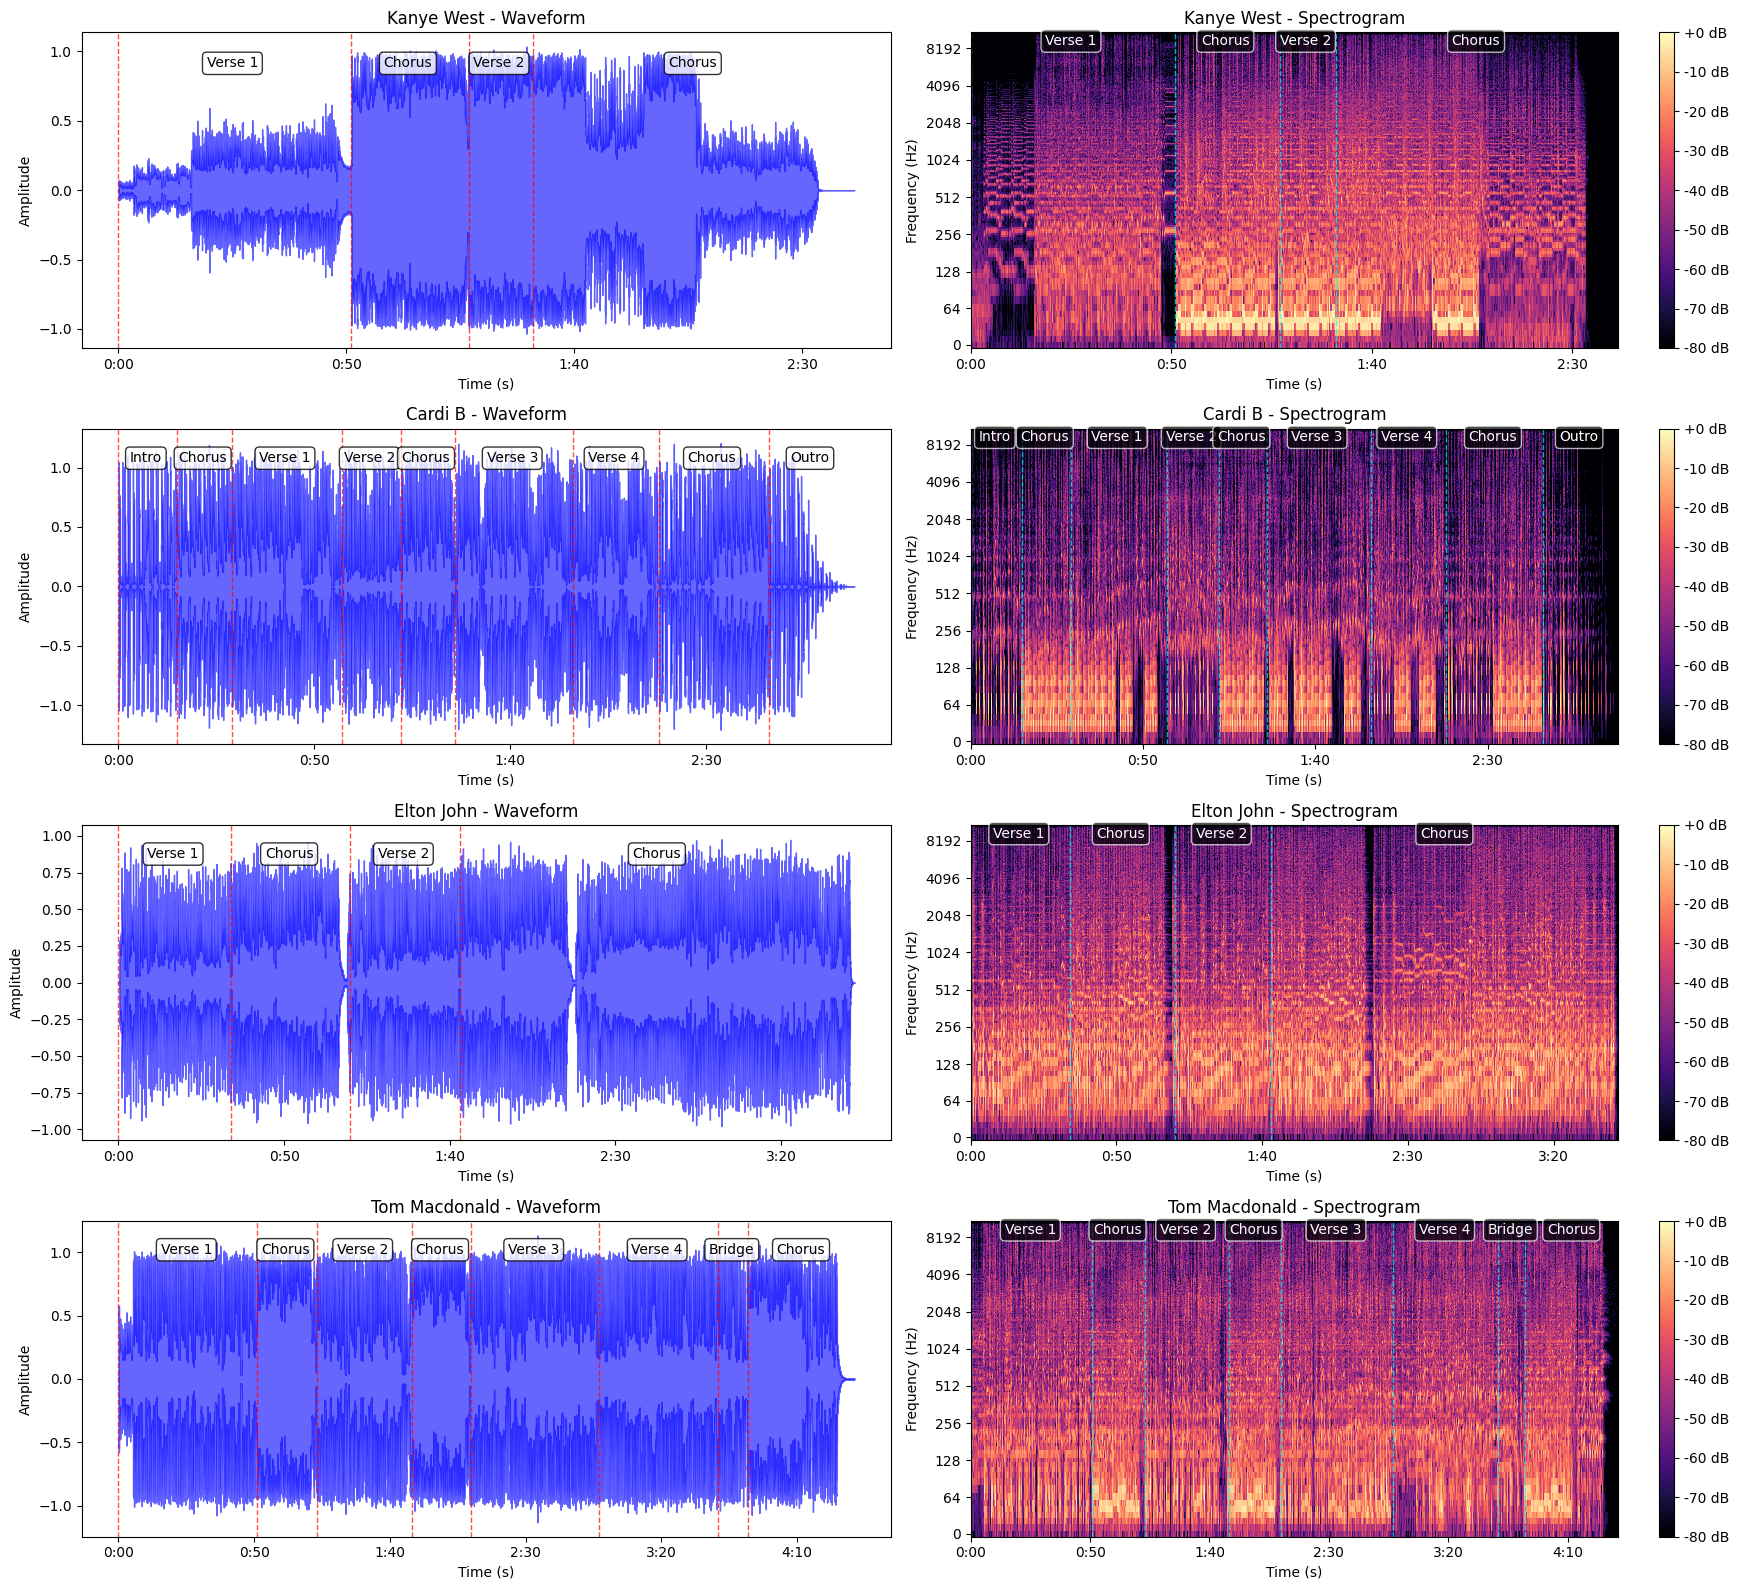

In [ ]:


plt.figure(figsize=(18, 16))  # Increased height for better spacing

for i, (artist, data) in enumerate(songs.items(), 1):
    y = data['y']
    sr = data['sr']
    
    # --- Waveform ---
    ax1 = plt.subplot(4, 2, 2*i-1)
    librosa.display.waveshow(y, sr=sr, ax=ax1, color='b', alpha=0.6)
    ax1.set(title=f'{artist} - Waveform', xlabel='Time (s)', ylabel='Amplitude')
    
    # Add section markers (customized for waveform)
    for start, end, label in song_sections[artist]:
        ax1.axvline(x=start, color='r', linestyle='--', linewidth=1, alpha=0.7)
        ax1.text(
            x=start + (end-start)/2,  # Center label in section
            y=0.9 * max(y),
            s=label,
            ha='center',
            va='center',
            bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3', alpha=0.8)
        )
    
    # --- Spectrogram ---
    ax2 = plt.subplot(4, 2, 2*i)
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    img = librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log', ax=ax2, cmap='magma')
    plt.colorbar(img, ax=ax2, format='%+2.0f dB')
    ax2.set(title=f'{artist} - Spectrogram', xlabel='Time (s)', ylabel='Frequency (Hz)')
    
    # Add section markers (customized for spectrogram)
    for start, end, label in song_sections[artist]:
        ax2.axvline(x=start, color='cyan', linestyle='--', linewidth=1, alpha=0.7)
        ax2.text(
            x=start + (end-start)/2,
            y=ax2.get_ylim()[1] * 0.85,  # Place near top of spectrogram
            s=label,
            ha='center',
            va='center',
            color='white',
            bbox=dict(facecolor='black', edgecolor='white', boxstyle='round,pad=0.3', alpha=0.7),
            
        )

plt.tight_layout()
plt.show()

In [37]:


def extract_intensity(y, sr):
    S = np.abs(librosa.stft(y))
    intensity_db = librosa.amplitude_to_db(S, ref=np.max)
    return np.mean(intensity_db)



def extract_audio_features(y, sr):
    # MFCCs
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfccs_mean = mfccs.mean(axis=1)
    
    # Spectral features
    spec_centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    spec_bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))
    spec_flatness = np.mean(librosa.feature.spectral_flatness(y=y))
    zero_cross_rate = np.mean(librosa.feature.zero_crossing_rate(y))
    
    # Tempo
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    
    return {
        **{f"mfcc_{i+1}": val for i, val in enumerate(mfccs_mean)},
        "spectral_centroid": spec_centroid,
        "spectral_bandwidth": spec_bandwidth,
        "spectral_flatness": spec_flatness,
        "zero_cross_rate": zero_cross_rate,
        "tempo": tempo
    }

In [38]:
results = []

for name, data in songs.items():
    y, sr = data["y"], data["sr"]
    
    intensity = extract_intensity(y, sr)
    audio_feats = extract_audio_features(y, sr)
    
    track_result = {
        "artist": name,
        "intensity": intensity,
        **audio_feats
    }
    
    results.append(track_result)

In [51]:
df = pd.DataFrame(results)

# Optional: round certain columns for readability
df['tempo'] = df['tempo'].apply(lambda x: x[0].round(2))
for col in df.columns:
    if col.startswith("mfcc_"):
        df[col] = df[col].round(2)



# Save to CSV
df.to_csv("song_features.csv", index=False)

In [52]:
df

,artist,intensity,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,spectral_centroid,spectral_bandwidth,spectral_flatness,zero_cross_rate,tempo
0,Kanye West,-60.148338,-111.970001,114.349998,-8.92,17.76,4.23,6.90,-2.05,5.28,-2.16,4.21,-2.31,3.62,-1.06,1651.269802,1972.668768,0.053582,0.061830,99.38
1,Cardi B,-61.926708,-128.550003,73.570000,11.50,20.16,10.72,8.02,7.88,7.94,3.30,-0.28,1.20,4.28,0.57,2490.556707,2602.073360,0.023677,0.103894,136.00
2,Elton John,-52.378834,-82.629997,91.650002,14.56,22.85,8.90,13.41,2.07,6.95,-2.18,3.89,-2.88,1.30,-2.46,2287.285266,2665.623299,0.017695,0.088978,143.55
3,Tom Macdonald,-50.247265,-14.320000,76.959999,-3.75,24.16,9.17,13.66,2.16,12.86,-4.95,2.10,-0.23,4.99,-1.99,2718.779978,2586.048669,0.037493,0.128864,86.13


C:\Users\jiyon\AppData\Local\Temp\ipykernel_26020\1880580618.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="artist", y="spectral_centroid", palette="viridis")


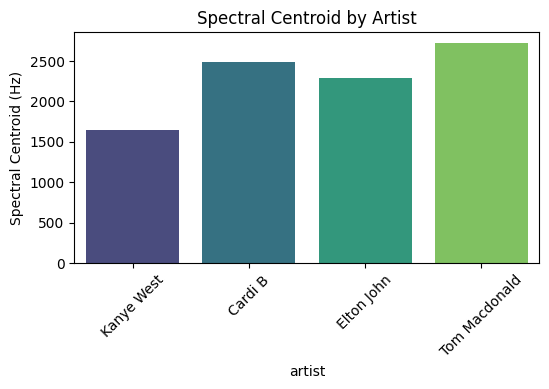

In [61]:
plt.figure(figsize=(6,3))
sns.barplot(data=df, x="artist", y="spectral_centroid", palette="viridis")
plt.title("Spectral Centroid by Artist")
plt.ylabel("Spectral Centroid (Hz)")
plt.xticks(rotation=45)
plt.show()


Higher spectral centroid - brighter, sharper

Lower specrtal centroid - darker, warmer, duller

C:\Users\jiyon\AppData\Local\Temp\ipykernel_26020\3658262724.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="artist", y="spectral_flatness", palette="plasma")


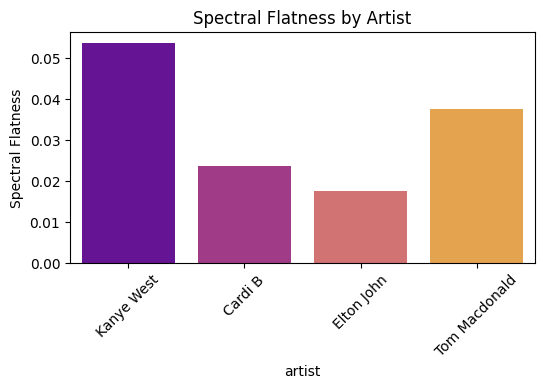

In [62]:
plt.figure(figsize=(6,3))
sns.barplot(data=df, x="artist", y="spectral_flatness", palette="plasma")
plt.title("Spectral Flatness by Artist")
plt.ylabel("Spectral Flatness")
plt.xticks(rotation=45)
plt.show()


Higher flatness means noisier, lower is pure singing note like a flute

C:\Users\jiyon\AppData\Local\Temp\ipykernel_26020\1933858023.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="artist", y="spectral_bandwidth", palette="Set2")


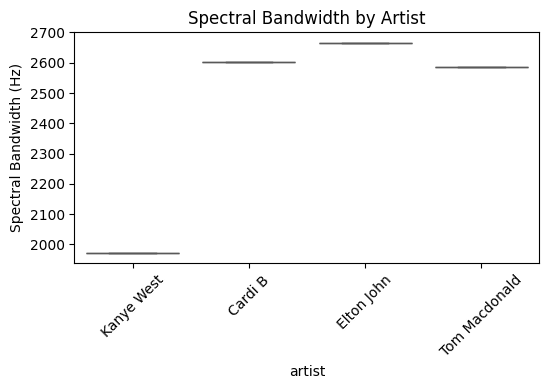

In [63]:
plt.figure(figsize=(6,3))
sns.boxplot(data=df, x="artist", y="spectral_bandwidth", palette="Set2")
plt.title("Spectral Bandwidth by Artist")
plt.ylabel("Spectral Bandwidth (Hz)")
plt.xticks(rotation=45)
plt.show()


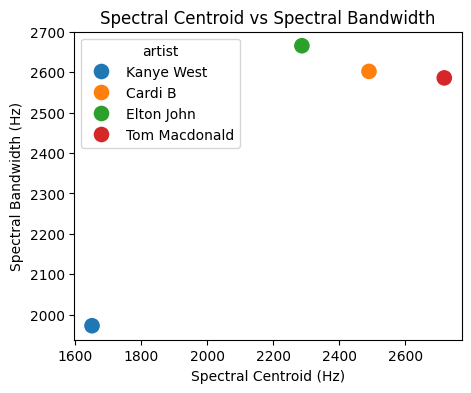

In [64]:
plt.figure(figsize=(5,4))
sns.scatterplot(
    data=df,
    x="spectral_centroid",
    y="spectral_bandwidth",
    hue="artist",
    s=150,
    palette="tab10"
)
plt.title("Spectral Centroid vs Spectral Bandwidth")
plt.xlabel("Spectral Centroid (Hz)")
plt.ylabel("Spectral Bandwidth (Hz)")
plt.show()


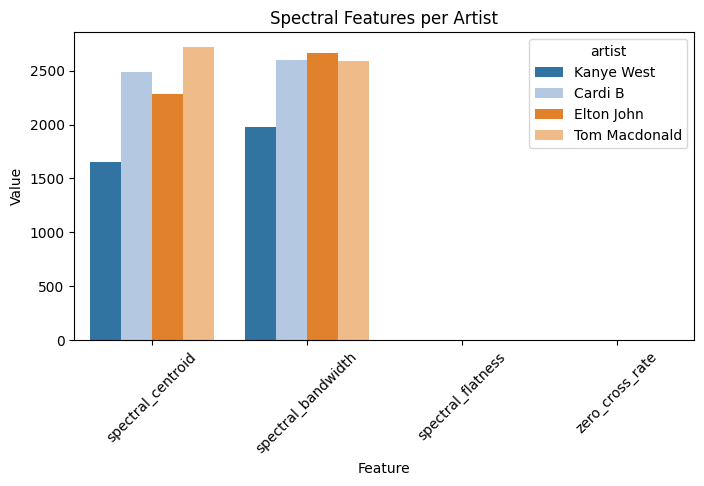

In [65]:
spectral_features = [
    "spectral_centroid",
    "spectral_bandwidth",
    "spectral_flatness",
    "zero_cross_rate"
]

# Melt for plotting
df_melted = df.melt(
    id_vars="artist",
    value_vars=spectral_features,
    var_name="Feature",
    value_name="Value"
)

plt.figure(figsize=(8,4))
sns.barplot(
    data=df_melted,
    x="Feature",
    y="Value",
    hue="artist",
    palette="tab20"
)
plt.title("Spectral Features per Artist")
plt.xticks(rotation=45)
plt.show()


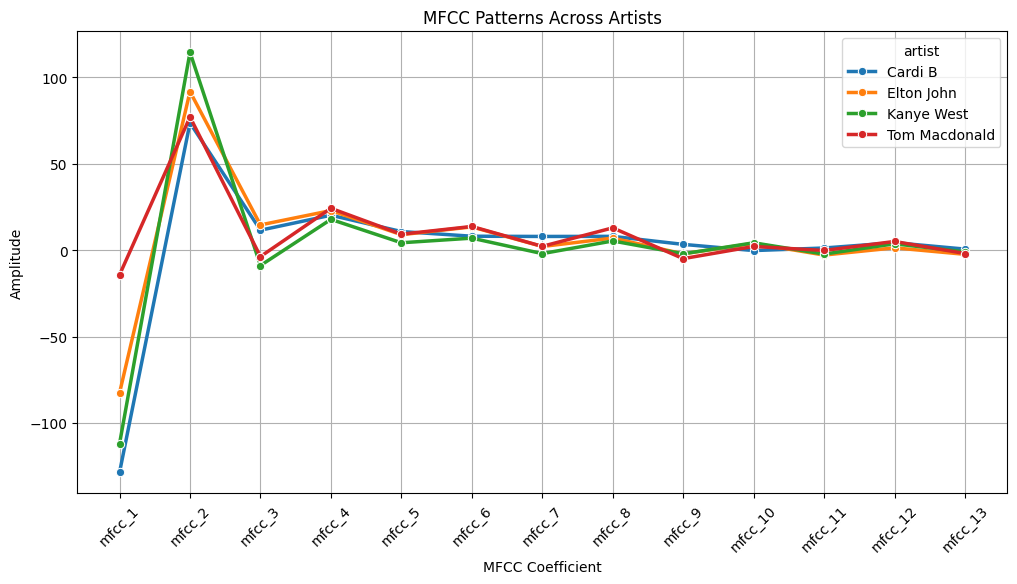

In [67]:
mfcc_cols = [f'mfcc_{i}' for i in range(1,14)]
avg_mfcc = df.groupby('artist')[mfcc_cols].mean().T.reset_index()
avg_mfcc = avg_mfcc.rename(columns={'index':'mfcc_coeff'})

# Melt for seaborn
melted = avg_mfcc.melt(id_vars='mfcc_coeff', var_name='artist', value_name='value')

# Plot
plt.figure(figsize=(12,6))
sns.lineplot(data=melted, x='mfcc_coeff', y='value', hue='artist', 
             marker='o', linewidth=2.5)
plt.title('MFCC Patterns Across Artists')
plt.xlabel('MFCC Coefficient')
plt.ylabel('Amplitude')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

MFCC 1	Average signal energy (loudness)	Overall track volume/amplitude

MFCC 2	Balance of low vs. high frequencies	Brightness/darkness of sound

MFCC 3	Mid-frequency spectral shape	Presence of vocals/instruments (300–1kHz)

MFCC 4	Harmonic structure	Distinguishes pitched vs. percussive sounds

MFCC 5	Mid-high frequency energy	Attack of instruments (1–3kHz)

MFCC 6–8	Spectral roughness/texture	Distortion, raspiness, or smoothness

MFCC 9–13	Fine spectral details	Reverb, noise, articulation nuances

In [7]:
!pip install plotly

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.6 MB 6.7 MB/s eta 0:00:02
   ---------- ----------------------------- 2.6/9.6 MB 6.6 MB/s eta 0:00:02
   ---------------- ----------------------- 3.9/9.6 MB 6.7 MB/s eta 0:00:01
   ---------------------- ----------------- 5.5/9.6 MB 6.7 MB/s eta 0:00:01
   ---------------------------- ----------- 6.8/9.6 MB 6.7 MB/s eta 0:00:01
   ---------------------------------- ----- 8.4/9.6 MB 6.8 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 6.7 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
from pyAudioAnalysis import audioTrainTest as aT
audio_file = "./song1/kanye.mp3"

# Pre-trained model for emotions
model_path = "pyAudioAnalysis/data/svmSpeechEmotion"  

# Classify emotion
Result, P, classNames = aT.file_classification(audio_file, model_path, "svm")
print(Result, P, classNames)
print("Predicted Class:", classNames[int(Result)])
print("Probabilities:", dict(zip(classNames, P)))

fileClassification: input model_name not found!
-1 -1 -1


TypeError: 'int' object is not subscriptable